In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
import time as t 
import random as rnd
import os
import io
import re
import matplotlib.pyplot as plt


seed = 42
rnd.seed(seed)
np.random.seed(seed)

print(f"Imported at: {t.ctime()}")

Imported at: Wed Mar 18 01:47:54 2026


In [2]:
results = "gat_results_heldout.csv"
df_results = pd.read_csv(results)
print(df_results.head())

names = ["0%", "33%", "67%"]

"""
Columns are: ["Dataset","Fold","Val_RMSE", "Val_MAE", "Val_Pearson", "Holdout_MSE", "Holdout_RMSE", "Holdout_MAE", "Holdout_R2", "Holdout_Rho", "Holdout_Pearson"]
What presentage synthetic they are from is in:

Dataset: "0%", "33%", "67%"
"""

zero_percent = df_results[df_results["Dataset"] == "0%"]
thirtythree_percent = df_results[df_results["Dataset"] == "33%"]
sixtyseven_percent = df_results[df_results["Dataset"] == "67%"]


  Dataset  Fold             Checkpoint  Val_RMSE   Val_MAE  Val_Pearson  \
0      0%     0  best_model_fold_0.pth  0.730896  0.562443     0.874491   
1      0%     1  best_model_fold_1.pth  0.669059  0.518041     0.837770   
2      0%     2  best_model_fold_2.pth  0.790969  0.622321     0.800394   
3      0%     3  best_model_fold_3.pth  0.840911  0.645190     0.802067   
4      0%     4  best_model_fold_4.pth  0.860493  0.659633     0.794233   

   Holdout_MSE  Holdout_RMSE  Holdout_MAE  Holdout_R2  Holdout_Rho  \
0     0.436620      0.660772     0.527187    0.592973     0.706312   
1     0.460869      0.678873     0.517469    0.570368     0.715333   
2     0.407092      0.638038     0.503544    0.620500     0.742129   
3     0.433996      0.658783     0.536805    0.595420     0.719035   
4     0.541901      0.736139     0.591343    0.494828     0.636859   

   Holdout_Pearson  
0         0.773573  
1         0.771031  
2         0.792331  
3         0.782186  
4         0.707966  


Plotting dataset from folder=./0%, file=MPNN_losses_0%.txt


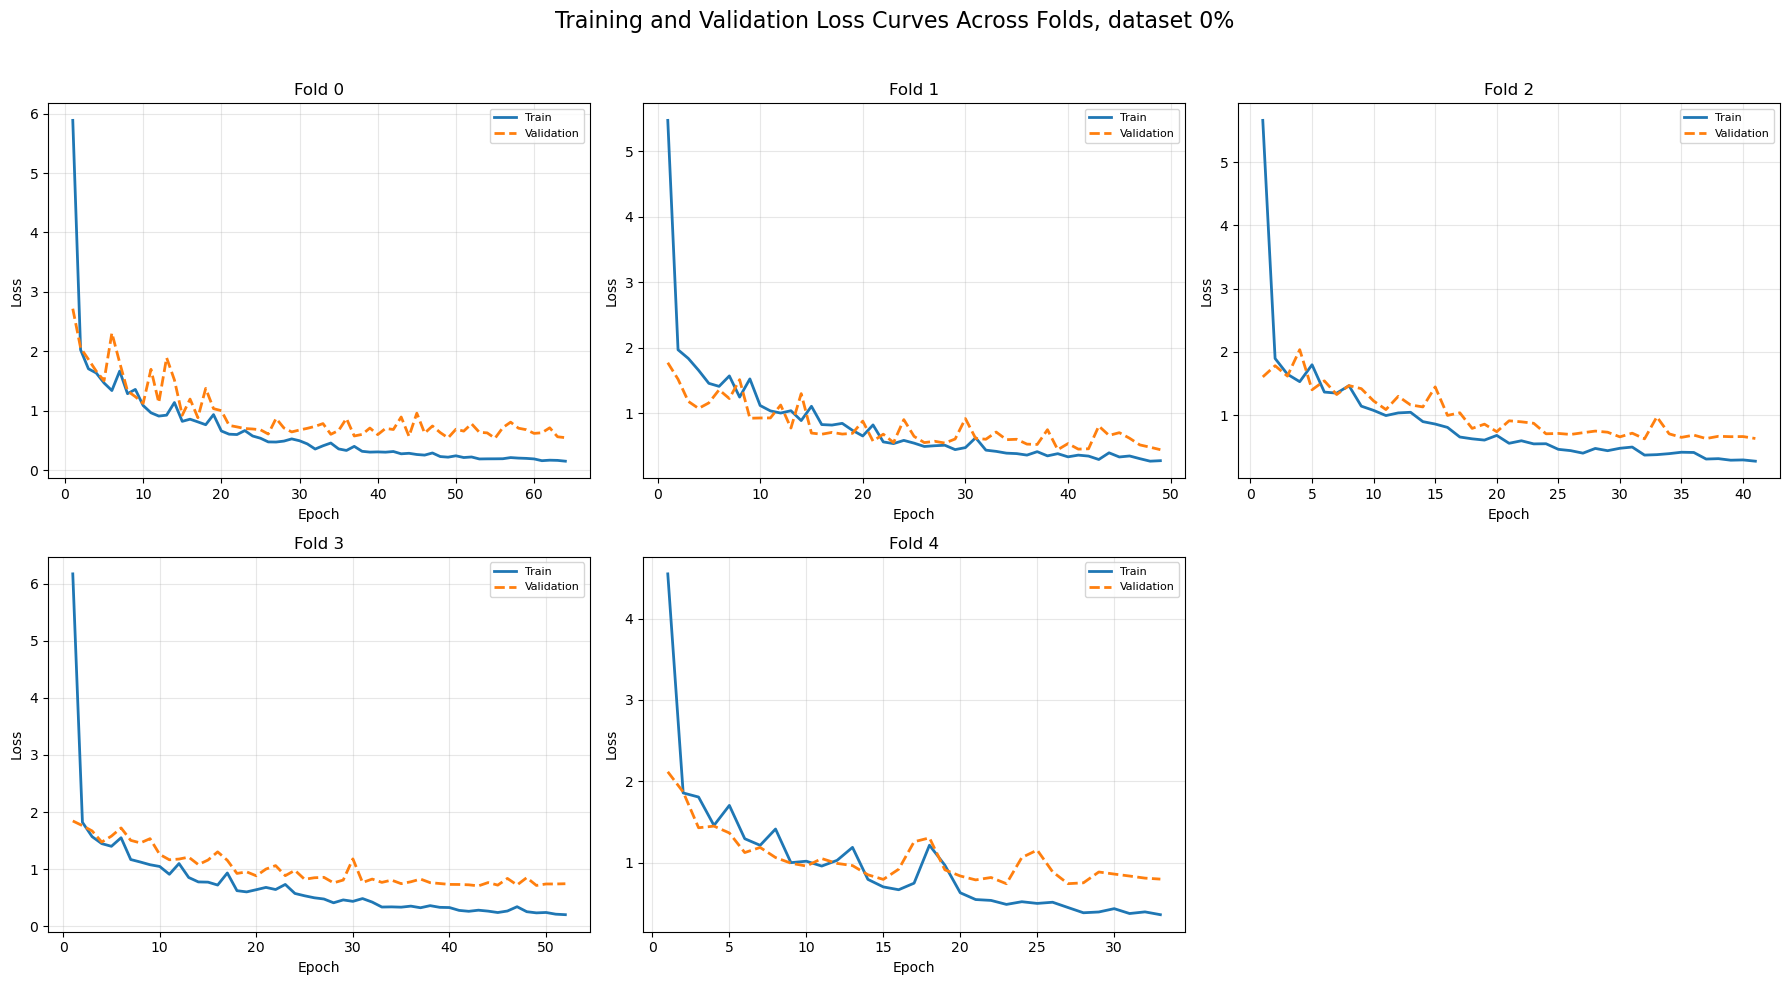

Plotting dataset from folder=./33%, file=MPNN_losses_33%.txt


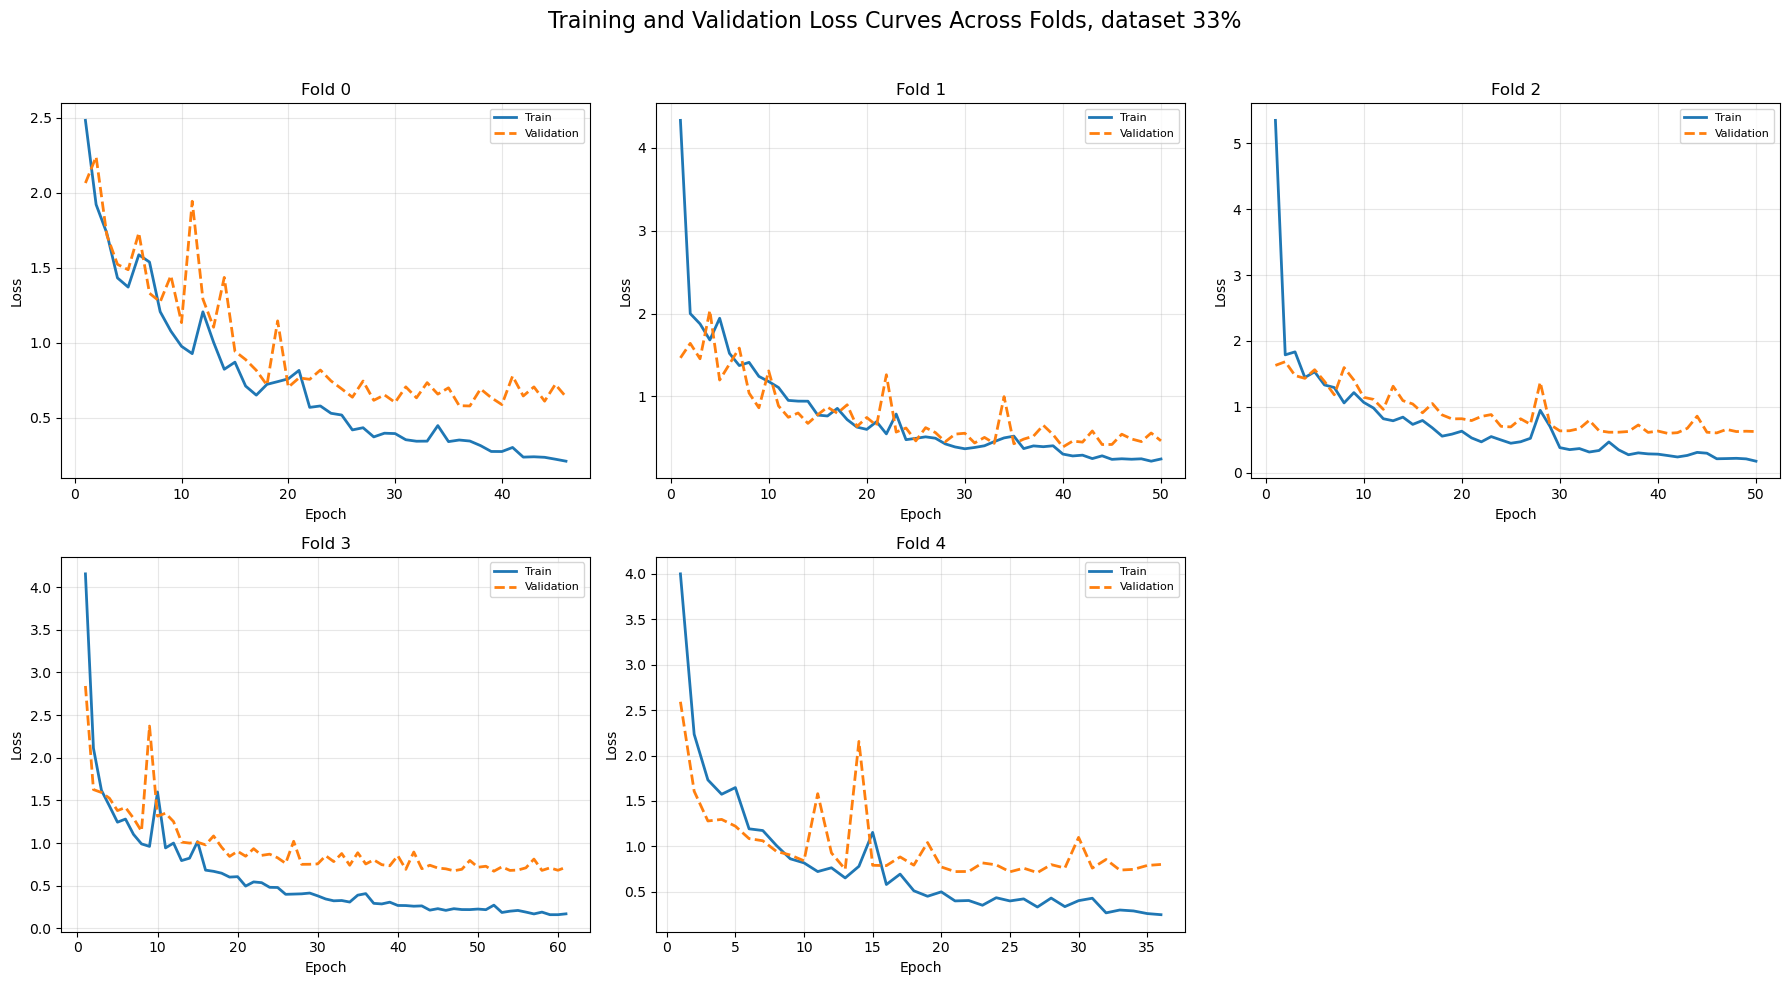

Plotting dataset from folder=./67%, file=MPNN_losses_67%.txt


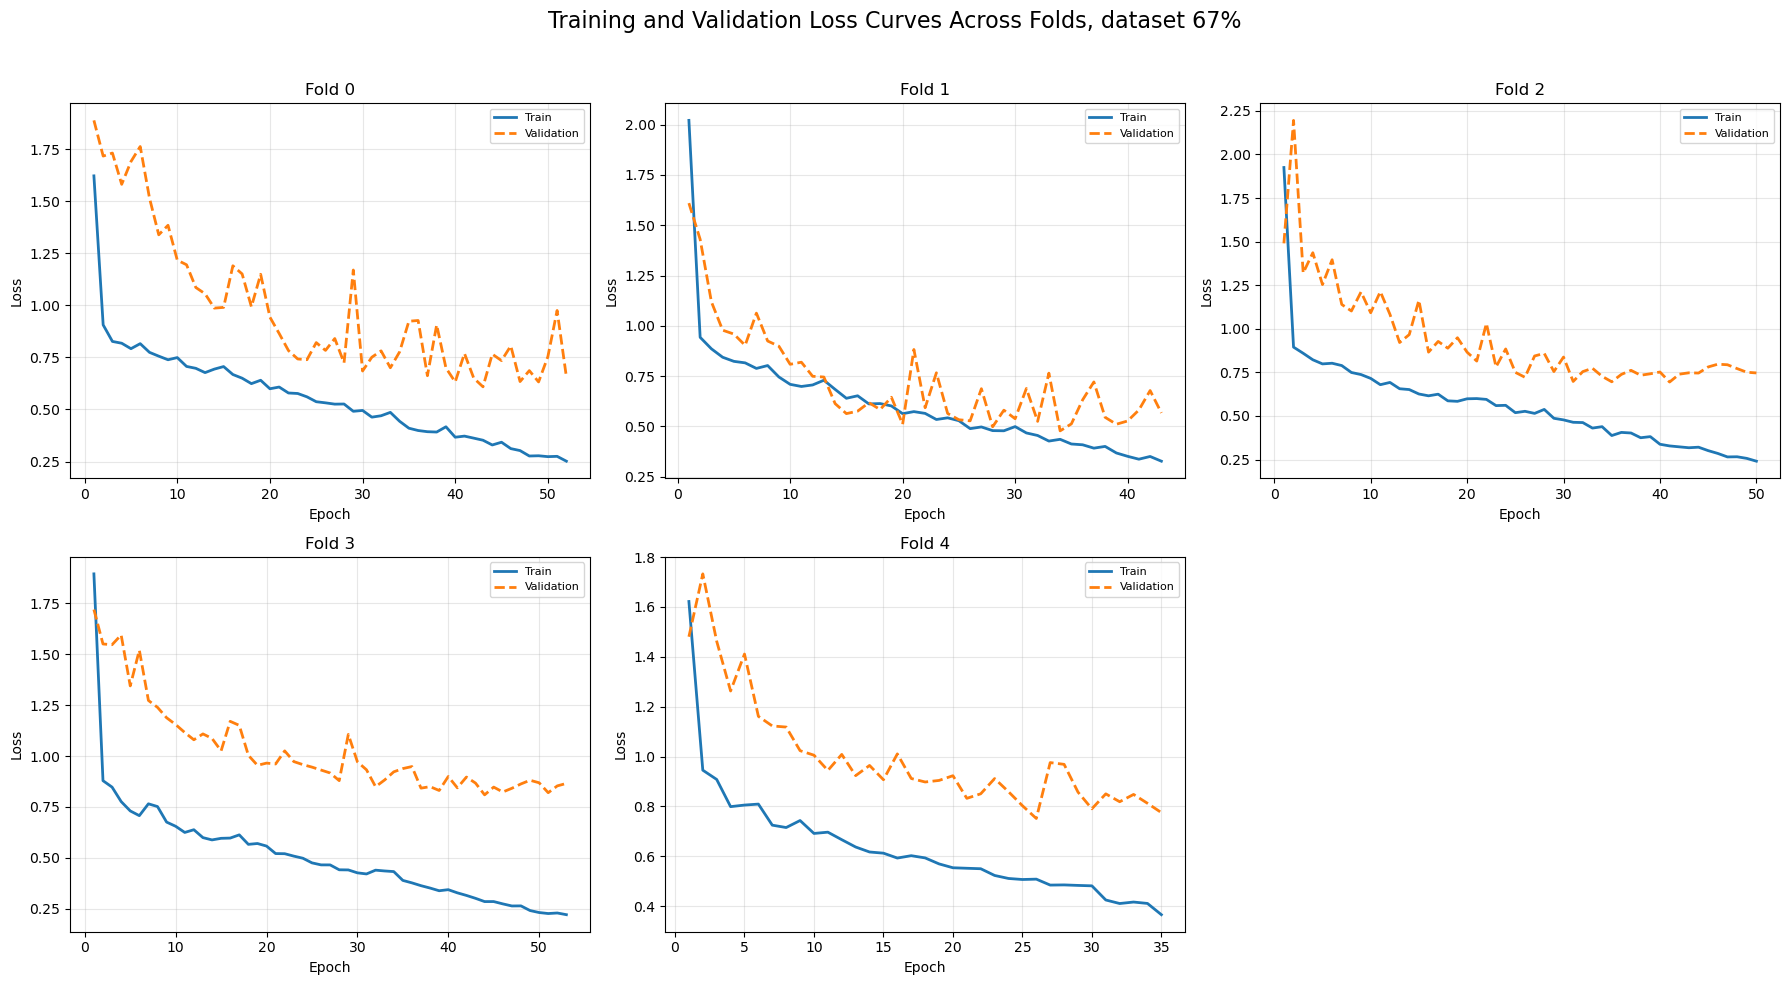

In [3]:
import os
import io
import re
import pandas as pd
import matplotlib.pyplot as plt


folders = ["./0%", "./33%", "./67%"]
path_in_folder = ["MPNN_losses_0%.txt", "MPNN_losses_33%.txt", "MPNN_losses_67%.txt"]


def load_fold_loss_file(file_path: str) -> dict[int, pd.DataFrame]:
    """
    Read a custom loss file with sections like:

    fold_0:
       train      val  monitor       lr
    5.560307 2.158475 1.469175 0.001000
    ...

    fold_1:
       train      val  monitor       lr
    ...

    Returns:
        dict mapping fold index -> DataFrame with columns:
        ['train', 'val', 'monitor', 'lr']
    """
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Split on lines like "fold_0:", "fold_1:", ...
    parts = re.split(r"(fold_\d+:)\s*", text)

    fold_data = {}

    # parts looks like:
    # [text_before, 'fold_0:', content0, 'fold_1:', content1, ...]
    for i in range(1, len(parts), 2):
        fold_header = parts[i].strip()
        fold_block = parts[i + 1].strip()

        match = re.match(r"fold_(\d+):", fold_header)
        if not match:
            continue

        fold_idx = int(match.group(1))

        # Remove empty lines inside block
        lines = [line.rstrip() for line in fold_block.splitlines() if line.strip()]
        if not lines:
            continue

        # Rebuild mini-table text for pandas
        block_text = "\n".join(lines)

        # Parse whitespace-separated mini table
        df = pd.read_csv(io.StringIO(block_text), sep=r"\s+")


        fold_data[fold_idx] = df

    return fold_data


def plot_loss_curves_subplots(
    folder: str,
    filename: str,
    max_folds: int = 5,
    figsize: tuple[int, int] = (18, 10),
):
    """
    Plot one dataset in one large figure with 5 smaller subplots,
    one subplot per fold.

    Parameters
    ----------
    folder : str
        Folder containing the loss file, for example "./0%".
    filename : str
        Name of the loss file, for example "MPNN_losses_0%.txt".
    max_folds : int
        Number of folds to plot.
    figsize : tuple[int, int]
        Figure size.
    """
    file_path = os.path.join(folder, filename)

    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found. Skipping this dataset.")
        return

    try:
        fold_data = load_fold_loss_file(file_path)
    except Exception as e:
        print(f"Warning: failed to parse {file_path}: {e}")
        return

    if not fold_data:
        print(f"No valid fold data found in {file_path}.")
        return

    dataset_label = os.path.basename(os.path.normpath(folder))

    # Create 2x3 grid, hide the last subplot if only 5 folds
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for fold_idx in range(max_folds):
        ax = axes[fold_idx]

        if fold_idx not in fold_data:
            ax.set_title(f"Fold {fold_idx} (missing)")
            ax.axis("off")
            continue

        df = fold_data[fold_idx]
        epochs = range(1, len(df) + 1)

        ax.plot(epochs, df["train"], label="Train", linewidth=2)
        ax.plot(epochs, df["val"], label="Validation", linestyle="--", linewidth=2)

        ax.set_title(f"Fold {fold_idx}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # Hide unused axes
    for i in range(max_folds, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        f"Training and Validation Loss Curves Across Folds, dataset {dataset_label}",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def iterate_datasets(
    folders: list[str],
    filenames: list[str],
    max_folds: int = 5,
    figsize: tuple[int, int] = (18, 10),
):
    """
    Iterate over datasets and plot one figure per dataset.

    Parameters
    ----------
    folders : list[str]
        Dataset folders, for example ["./0%", "./33%", "./67%"].
    filenames : list[str]
        Matching filenames for each folder.
    max_folds : int
        Number of folds to plot.
    figsize : tuple[int, int]
        Figure size.
    """
    if len(folders) != len(filenames):
        raise ValueError("folders and filenames must have the same length.")

    for folder, filename in zip(folders, filenames):
        print(f"Plotting dataset from folder={folder}, file={filename}")
        plot_loss_curves_subplots(
            folder=folder,
            filename=filename,
            max_folds=max_folds,
            figsize=figsize,
        )


iterate_datasets(folders, path_in_folder)

  Dataset  Fold             Checkpoint  Val_RMSE   Val_MAE  Val_Pearson  \
0      0%     0  best_model_fold_0.pth  0.742373  0.573282     0.870860   
1      0%     1  best_model_fold_1.pth  0.634501  0.487745     0.855425   
2      0%     2  best_model_fold_2.pth  0.793666  0.611396     0.799234   
3      0%     3  best_model_fold_3.pth  0.822630  0.632388     0.812835   
4      0%     4  best_model_fold_4.pth  0.851512  0.632408     0.800030   

   Holdout_MSE  Holdout_RMSE  Holdout_MAE  Holdout_R2  Holdout_Rho  \
0     0.555092      0.745045     0.581056    0.482531     0.663025   
1     0.493765      0.702684     0.556164    0.539702     0.707929   
2     0.517840      0.719611     0.586429    0.517258     0.692662   
3     0.446401      0.668132     0.527567    0.583856     0.717726   
4     0.597786      0.773166     0.601859    0.442731     0.613896   

   Holdout_Pearson  
0         0.731071  
1         0.752827  
2         0.751448  
3         0.776630  
4         0.678127  
['

C:\Users\kjo02\AppData\Local\Temp\ipykernel_32496\2533768652.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_32496\2533768652.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_32496\2533768652.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


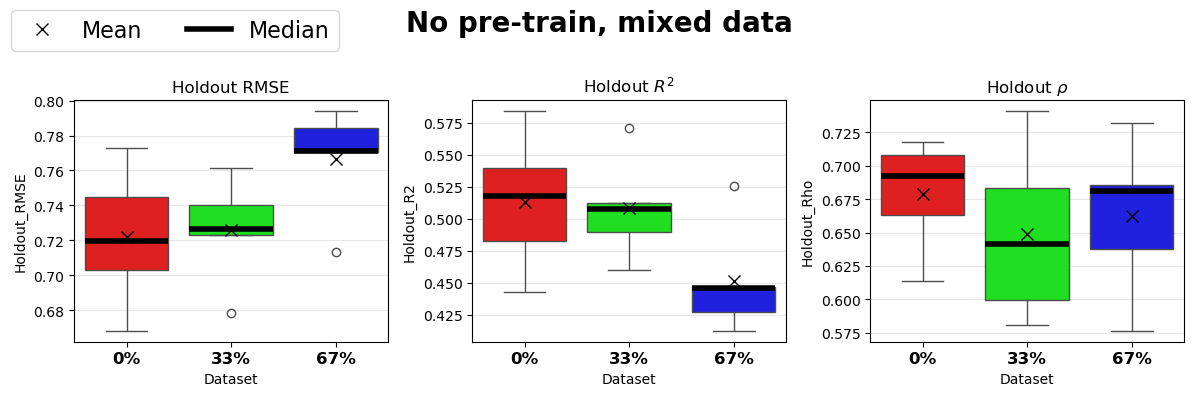

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import os 
import numpy as np




def simple_metric_boxplots(df: pd.DataFrame, metrics: str | list[str], title: str = "Boxplots",folder:str | None = None, save: str | None = None):
    if isinstance(metrics, str):
        metrics = [metrics]

    amount = len(metrics)
    n_per_row = min(3, amount)  # max 3 plots per row for better aesthetics
    rows = (amount + n_per_row - 1) // n_per_row  # calculate number of rows needed
    fig, axs = plt.subplots(rows, n_per_row, figsize=(4 * n_per_row, 4 * rows)) # Adjust figure size based on number of plots

    if len(metrics) == 1:
        axs = [axs]
    


    def subplot_titles_match(name: str) -> str:
        possible = {"Holdout_R2": "Holdout R2",
            "Holdout_Rho": fr"Holdout $\rho$",
            "Holdout_RMSE": fr"Holdout RMSE",
            "Holdout_MAE": fr"Holdout MAE",
            "Holdout_R2": fr"Holdout $R^2$",
            "Holdout_Pearson": fr"Holdout Pearson/$r$",
            "Val_RMSE": fr"Validation RMSE",
            "Val_MAE": fr"Validation MAE",
            "Val_Pearson": fr"Validation Pearson/$r$"
            
            }
        return possible.get(name, name)
    



    axs = np.atleast_1d(axs).flatten()
    plot_df = df[df["Dataset"].isin(names)].copy()

    colors = ['#FF0000', '#00FF00', '#0000FF']  # Red, Green, Blue for the three datasets
    #colors = sns.color_palette("tab10", n_colors=len(metrics))  # Seaborn Set2 palette for better aesthetics
    idx = 0



    for ax, metric in zip(axs, metrics):
        if metric not in plot_df.columns:
            ax.set_visible(False)
            print(f"Warning: metric '{metric}' not found in dataframe columns.")
            continue

        # For the legend!!!
        # SNS cant have a legend for mean and median....
        mean_handle = Line2D( [0], [0], marker='x', color='w', markerfacecolor='white', markeredgecolor='black', markersize=8, label='Mean')

        median_handle = Line2D( [0], [0], color='black', linewidth=4, label='Median')


        sns.boxplot(
            x="Dataset",
            y=metric,
            data=plot_df,
            order=names,
            ax=ax,
            showfliers=True,
            palette=colors,
            showmeans=True,
            meanprops={"marker": "x", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
            medianprops={
                "linewidth": 4,
                "color": "black"
            }
        )
        
        ax.set_title(subplot_titles_match(metric))
        ax.set_xlabel("Dataset")
        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.3)
        for label in ax.get_xticklabels():
            label.set_fontsize(12)
            label.set_fontweight('bold')
    # Hide any unused subplot axes
    for ax in axs[len(metrics):]:
        ax.set_visible(False)
    fig.legend( handles=[mean_handle, median_handle], loc='upper left', ncol=3, fontsize=16, frameon=True)
    fig.suptitle(title, fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    save_folder = folder
    out = os.path.join(save_folder, f"{save}.pdf")
    plt.savefig(out, dpi=300)  # Save the figure as a high-resolution PDF file
    plt.show()


"""
Columns are: ["Dataset","Fold","Val_RMSE", "Val_MAE", "Val_Pearson", "Holdout_MSE", "Holdout_RMSE", "Holdout_MAE", "Holdout_R2", "Holdout_Rho", "Holdout_Pearson"]
What presentage synthetic they are from is in:

Dataset: "0%", "33%", "67%"
"""
mode = "no_pretrain" # "pretrain or no_pretrain"

if mode == "pretrain":
    folder = "pretrain"
    results = "gat_results_heldout.csv"
    title = "Pre-train(synth), no synth train"
    save = "pretrain_metrics"
elif mode == "no_pretrain":
    folder = "no_pretrain"
    results = "MPNN_results_heldout_set.csv"
    title = "No pre-train, mixed data"
    save = "no_pretrain_metrics"


#title = "No_pre_training_mixed_datasets,_with_MPNN"
results = os.path.join(folder, results)
df_results = pd.read_csv(results)

print(df_results.head())
print(df_results.columns.tolist())

names = ["0%", "33%", "67%"]

simple_metric_boxplots(df_results,["Holdout_RMSE","Holdout_R2", "Holdout_Rho"], title=title, folder=folder,save=save)




Loaded prediction file
Shape: (3000, 6)
Unique datasets: ['0%', '33%', '67%']
Unique folds: [0, 1, 2, 3, 4]
Unique molecules: 200

Example molecule-level rows for dataset 0%:


Fold summary across datasets:
   Dataset  Fold  n_rows  n_unique_molecules      RMSE       MAE
0       0%     0     200                 200  0.667553  0.535513
1       0%     1     200                 200  0.660557  0.526294
2       0%     2     200                 200  0.680294  0.553043
3       0%     3     200                 200  0.659587  0.521913
4       0%     4     200                 200  0.739311  0.597508
5      33%     0     200                 200  0.774370  0.598270
6      33%     1     200                 200  0.705144  0.551415
7      33%     2     200                 200  0.728667  0.599137
8      33%     3     200                 200  0.710400  0.567980
9      33%     4     200                 200  0.745523  0.599042
10     67%     0     200                 200  0.680687  0.525609
11     67%  

C:\Users\juan\AppData\Local\Temp\ipykernel_2700\1913594371.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Dataset", y="RMSE", data=fold_rmse_df, order=sorted(fold_rmse_df["Dataset"].unique()), palette=colors)


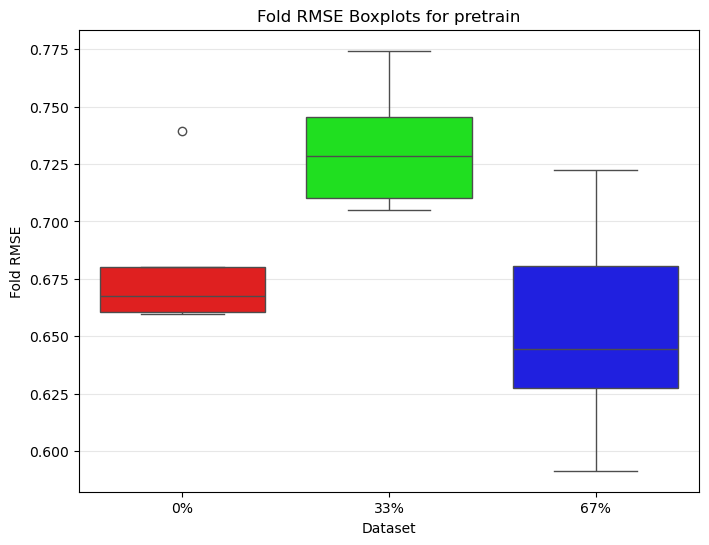


Dataset summary of fold RMSE
  Dataset  mean_fold_rmse  median_fold_rmse  std_fold_rmse  mean_fold_mae
0      0%        0.681460          0.667553       0.033380       0.546854
1     33%        0.732821          0.728667       0.028168       0.583169
2     67%        0.653312          0.644488       0.050238       0.518590

Dataset summary of molecule RMSE
  Dataset  n_molecules  mean_molecule_rmse  median_molecule_rmse  \
0      0%          200            0.589654              0.493826   
1     33%          200            0.635149              0.563996   
2     67%          200            0.560287              0.471021   

   std_molecule_rmse  mean_molecule_mae  
0           0.343772           0.546854  
1           0.367316           0.583169  
2           0.339840           0.518590  

Dataset summary of molecule RMSE plot:


C:\Users\juan\AppData\Local\Temp\ipykernel_2700\1913594371.py:341: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Dataset", y="Molecule_RMSE", data=molecule_rmse_df, order=sorted(molecule_rmse_df["Dataset"].unique(),), palette=colors)


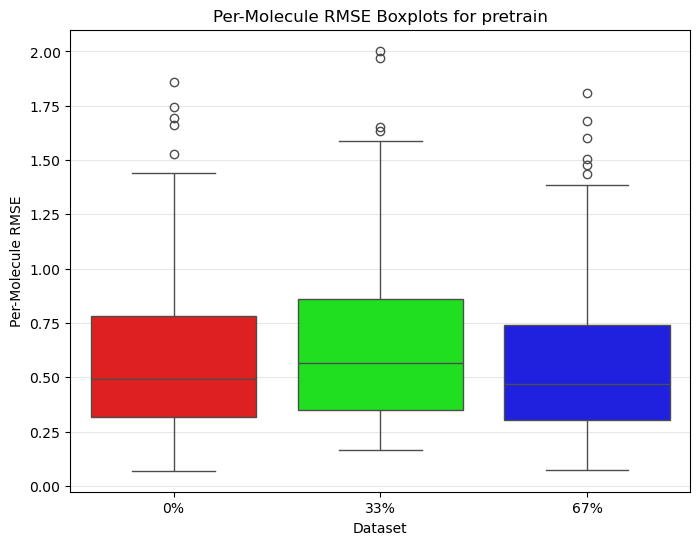

In [13]:
# ==============================================================================
# CHANGELOG
# ==============================================================================
# v2.0
# - Kept the overall structure of your script.
# - Fixed and clarified the distinction between:
#     1. Per-fold RMSE across molecules
#     2. Per-molecule RMSE across the 5 folds
# - Added validation that required columns exist.
# - Added validation that Fold is integer.
# - Added validation that each molecule inside each dataset has exactly folds
#   [0, 1, 2, 3, 4].
# - Added a fold-level summary across datasets.
# - Kept optional saving with a single save toggle.
# - Removed no needed logic ambiguity around molecule vs fold RMSE.
# ==============================================================================

"""

    Load predictions from a CSV file with columns:
    Dataset	Fold	Checkpoint	smiles	True_pIC50	Pred_pIC50
    0%	0	best_model_fold_0.pth	CN1C(=O)C2(CC(C)(C)Oc3ccc(-c4ccsn4)cc32)N=C1N	6.3001623	6.866766
    0%	0	best_model_fold_0.pth	CN1C(=O)[C@@](c2ccc(OC(F)F)cc2)(c2cccc(/C=C/CCCO)c2)N=C1N	7.39794	7.1644454
    0%	0	best_model_fold_0.pth	CN1C(=O)[C@@](c2ccc(OC(F)F)cc2)(c2cccc(C(=O)CCCF)c2)N=C1N	7.09691	7.2256165

    Returns a DataFrame with these columns.


"""



import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import time as t
import random as r
import os
import seaborn as sns


def load_predictions(file_path: str) -> pd.DataFrame:
    """
    Load predictions from a CSV file with columns such as:
    Dataset, Fold, Checkpoint, smiles, True_pIC50, Pred_pIC50

    Returns a DataFrame with the loaded data and basic validation.
    """
    df = pd.read_csv(file_path)

    expected_columns = {"Dataset", "Fold", "smiles", "True_pIC50", "Pred_pIC50"}
    missing = expected_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Make sure Fold is numeric and consistently sorted later
    df["Fold"] = df["Fold"].astype(int)

    return df


def sort_by_dataset(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Given a DataFrame with a 'Dataset' column, return a dictionary mapping
    dataset name to the subset of the DataFrame for that dataset.
    """
    datasets = df["Dataset"].unique()
    return {dataset: df[df["Dataset"] == dataset].copy() for dataset in datasets}


def per_dataset_per_molecule(
    df: pd.DataFrame,
    folder: str | None = None,
    datasets: dict[str, pd.DataFrame] | None = None
) -> dict[str, pd.DataFrame]:
    """
    For each dataset, return a DataFrame with one row per molecule.

    Output columns:
    - Smiles
    - True_pIC50
    - Folds
    - Pred_pIC50s
    - Errors

    Important:
    The predictions are sorted by fold so fold order is explicit and stable.
    """
    if datasets is None:
        datasets = sort_by_dataset(df)

    dataset_molecule_data = {}

    for dataset_name, dataset_df in datasets.items():
        molecule_groups = dataset_df.groupby("smiles", sort=False)

        molecule_data = []
        for smiles, group in molecule_groups:
            group = group.sort_values("Fold").reset_index(drop=True)

            true_values = group["True_pIC50"].unique()
            if len(true_values) != 1:
                raise ValueError(
                    f"Dataset {dataset_name}, molecule {smiles} has multiple True_pIC50 values: {true_values}"
                )

            true_pIC50 = true_values[0]
            folds = group["Fold"].tolist()

            # Validate that each molecule appears once in each of the 5 folds
            expected_folds = [0, 1, 2, 3, 4]
            if folds != expected_folds:
                raise ValueError(
                    f"Dataset {dataset_name}, molecule {smiles} has folds {folds}, expected {expected_folds}"
                )

            pred_pIC50s = group["Pred_pIC50"].tolist()
            errors = (group["Pred_pIC50"] - true_pIC50).tolist()

            molecule_data.append({
                "Smiles": smiles,
                "True_pIC50": true_pIC50,
                "Folds": folds,
                "Pred_pIC50s": pred_pIC50s,
                "Errors": errors
            })

        dataset_molecule_data[dataset_name] = pd.DataFrame(molecule_data)

    return dataset_molecule_data


def per_fold_rmse(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute one RMSE value for each dataset and fold.

    This is the standard fold-level RMSE:
    for each (Dataset, Fold), aggregate over all molecules in that fold.

    Returns columns:
    - Dataset
    - Fold
    - n_rows
    - n_unique_molecules
    - RMSE
    - MAE
    """
    df = df.copy()
    df["residual"] = df["Pred_pIC50"] - df["True_pIC50"]
    df["squared_error"] = df["residual"] ** 2
    df["abs_error"] = df["residual"].abs()

    records = []

    grouped = df.groupby(["Dataset", "Fold"], sort=True)
    for (dataset_name, fold), group in grouped:
        rmse = np.sqrt(group["squared_error"].mean())
        mae = group["abs_error"].mean()

        records.append({
            "Dataset": dataset_name,
            "Fold": int(fold),
            "n_rows": len(group),
            "n_unique_molecules": group["smiles"].nunique(),
            "RMSE": rmse,
            "MAE": mae
        })

    return pd.DataFrame(records).sort_values(["Dataset", "Fold"]).reset_index(drop=True)


def summarize_fold_rmse(fold_rmse_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize the 5 fold RMSE values for each dataset.

    Returns columns:
    - Dataset
    - mean_fold_rmse
    - median_fold_rmse
    - std_fold_rmse
    - mean_fold_mae
    """
    summary = (
        fold_rmse_df
        .groupby("Dataset", sort=True)
        .agg(
            mean_fold_rmse=("RMSE", "mean"),
            median_fold_rmse=("RMSE", "median"),
            std_fold_rmse=("RMSE", "std"),
            mean_fold_mae=("MAE", "mean"),
        )
        .reset_index()
    )
    
    return summary


def per_molecule_rmse_across_folds(dataset_molecule_data: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    For each dataset and molecule, compute RMSE across the 5 fold predictions.

    This gives one RMSE per molecule per dataset.

    Returns columns:
    - Dataset
    - Smiles
    - True_pIC50
    - Folds
    - Pred_pIC50s
    - Errors
    - Molecule_RMSE
    - Molecule_MAE
    - Molecule_MedianAE
    """
    records = []

    for dataset_name, df_mol in dataset_molecule_data.items():
        for _, row in df_mol.iterrows():
            errors = np.array(row["Errors"], dtype=float)

            molecule_rmse = np.sqrt(np.mean(errors ** 2))
            molecule_mae = np.mean(np.abs(errors))
            molecule_median_ae = np.median(np.abs(errors))

            records.append({
                "Dataset": dataset_name,
                "Smiles": row["Smiles"],
                "True_pIC50": row["True_pIC50"],
                "Folds": row["Folds"],
                "Pred_pIC50s": row["Pred_pIC50s"],
                "Errors": row["Errors"],
                "Molecule_RMSE": molecule_rmse,
                "Molecule_MAE": molecule_mae,
                "Molecule_MedianAE": molecule_median_ae
            })

    return pd.DataFrame(records).sort_values(["Dataset", "Smiles"]).reset_index(drop=True)


def per_molecule_fold_error_table(dataset_molecule_data: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Create a wide table with one row per molecule per dataset and explicit fold columns.

    Useful for plotting or checking that each molecule has all 5 folds.

    Returns columns like:
    - Dataset
    - Smiles
    - True_pIC50
    - Pred_fold_0 ... Pred_fold_4
    - Error_fold_0 ... Error_fold_4
    """
    records = []

    for dataset_name, df_mol in dataset_molecule_data.items():
        for _, row in df_mol.iterrows():
            folds = row["Folds"]
            preds = row["Pred_pIC50s"]
            errors = row["Errors"]

            record = {
                "Dataset": dataset_name,
                "Smiles": row["Smiles"],
                "True_pIC50": row["True_pIC50"]
            }

            for fold, pred, err in zip(folds, preds, errors):
                record[f"Pred_fold_{fold}"] = pred
                record[f"Error_fold_{fold}"] = err

            records.append(record)

    return pd.DataFrame(records).sort_values(["Dataset", "Smiles"]).reset_index(drop=True)


def summarize_molecule_rmse(molecule_rmse_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize molecule-level RMSE distribution per dataset.

    Returns columns:
    - Dataset
    - n_molecules
    - mean_molecule_rmse
    - median_molecule_rmse
    - std_molecule_rmse
    - mean_molecule_mae
    """
    summary = (
        molecule_rmse_df
        .groupby("Dataset", sort=True)
        .agg(
            n_molecules=("Smiles", "count"),
            mean_molecule_rmse=("Molecule_RMSE", "mean"),
            median_molecule_rmse=("Molecule_RMSE", "median"),
            std_molecule_rmse=("Molecule_RMSE", "std"),
            mean_molecule_mae=("Molecule_MAE", "mean"),
        )
        .reset_index()
    )
    return summary

def plot_fold_rmse_boxplots(fold_rmse_df: pd.DataFrame, title: str = "Fold RMSE Boxplots", folder: str | None = None, save: str | None = None,should_save: bool = False):
    """
    Plot boxplots of fold RMSE values for each dataset.

    Parameters:
    - fold_rmse_df: DataFrame with columns ['Dataset', 'Fold', 'RMSE']
    - title: Title of the plot
    - folder: Optional folder to save the plot
    - save: Optional filename (without extension) to save the plot as PDF
    """
    colors = ['#FF0000', '#00FF00', '#0000FF']  # Red, Green, Blue for the three datasets['#FF0000', '#00FF00', '#0000FF']  # Red, Green, Blue for the three datasets
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="Dataset", y="RMSE", data=fold_rmse_df, order=sorted(fold_rmse_df["Dataset"].unique()), palette=colors)
    plt.title(title)
    plt.xlabel("Dataset")
    plt.ylabel("Fold RMSE")
    plt.grid(axis="y", alpha=0.3)

    if folder and save and should_save:
        out = os.path.join(folder, f"{save}.pdf")
        plt.savefig(out, dpi=300)
        print(f"Saved fold RMSE boxplot to {out}")

    plt.show()


def plot_per_molecule_rmse_boxplots(molecule_rmse_df: pd.DataFrame, title: str = "Per-Molecule RMSE Boxplots", folder: str | None = None, save: str | None = None, should_save: bool = False):
    """
    Plot boxplots of per-molecule RMSE values for each dataset.

    Parameters:
    - molecule_rmse_df: DataFrame with columns ['Dataset', 'Smiles', 'Molecule_RMSE']
    - title: Title of the plot
    - folder: Optional folder to save the plot
    - save: Optional filename (without extension) to save the plot as PDF
    """
    colors = ['#FF0000', '#00FF00', '#0000FF']  # Red, Green, Blue for the three datasets
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="Dataset", y="Molecule_RMSE", data=molecule_rmse_df, order=sorted(molecule_rmse_df["Dataset"].unique(),), palette=colors)
    plt.title(title)
    plt.xlabel("Dataset")
    plt.ylabel("Per-Molecule RMSE")
    plt.grid(axis="y", alpha=0.3)

    if folder and save and should_save:
        out = os.path.join(folder, f"{save}.pdf")
        plt.savefig(out, dpi=300)
        print(f"Saved per-molecule RMSE boxplot to {out}")

    plt.show()



# ==============================================================================
# MAIN
# ==============================================================================

folder = "pretrain"

if folder == "pretrain":
    results = "GAT_predictions_heldout_set.csv"
    predictions_file = os.path.join(folder, results)
elif folder == "no_pretrain":
    results = "MPNN_predictions_heldout_set.csv"
    predictions_file = os.path.join(folder, results)

save = False





############################################################












pred_df = load_predictions(predictions_file)
datasets = sort_by_dataset(pred_df)
dataset_molecule_data = per_dataset_per_molecule(pred_df, folder=folder, datasets=datasets)

print("\n" + "=" * 80)
print("Loaded prediction file")
print("=" * 80)
print(f"Shape: {pred_df.shape}")
print(f"Unique datasets: {sorted(pred_df['Dataset'].unique().tolist())}")
print(f"Unique folds: {sorted(pred_df['Fold'].unique().tolist())}")
print(f"Unique molecules: {pred_df['smiles'].nunique()}")

print("\nExample molecule-level rows for dataset 0%:")
#print(dataset_molecule_data["0%"].head())

# 1. Per fold RMSE across molecules


fold_rmse_summary = per_fold_rmse(pred_df)

#print("\n" + "=" * 80)
#print("Per-fold RMSE summary")
#print("=" * 80)
#print(fold_rmse_summary)

# 2. Fold-level summary per dataset

print("\n" + "=" * 80)


fold_rmse_dataset_summary = summarize_fold_rmse(fold_rmse_summary)

print("\n" + "=" * 80)
print("Fold summary across datasets:")
print("=" * 80)
print(fold_rmse_summary)


plot_fold_rmse_boxplots(fold_rmse_summary, title=f"Fold RMSE Boxplots for {folder}", folder=folder, save=f"{folder}_fold_rmse_boxplot",should_save=save)

print("\n" + "=" * 80)
print("Dataset summary of fold RMSE")
print("=" * 80)
print(fold_rmse_dataset_summary)

# 3. Per molecule RMSE across folds
molecule_rmse_summary = per_molecule_rmse_across_folds(dataset_molecule_data)

#print("\n" + "=" * 80)
#print("Per-molecule RMSE summary")
#print("=" * 80)
#print(molecule_rmse_summary.head())

# 4. Optional wide table with per-fold errors for each molecule
molecule_fold_error_table = per_molecule_fold_error_table(dataset_molecule_data)

#print("\n" + "=" * 80)
#print("Per-molecule wide fold table")
#print("=" * 80)
#print(molecule_fold_error_table.head())

# 5. Dataset-level summary of molecule RMSE
molecule_rmse_dataset_summary = summarize_molecule_rmse(molecule_rmse_summary)

print("\n" + "=" * 80)
print("Dataset summary of molecule RMSE")
print("=" * 80)
print(molecule_rmse_dataset_summary)
print("\n" + "=" * 80)
print("Dataset summary of molecule RMSE plot:")
plot_per_molecule_rmse_boxplots(molecule_rmse_summary, title=f"Per-Molecule RMSE Boxplots for {folder}", folder=folder, save=f"{folder}_per_molecule_rmse_boxplot",should_save=save)









if save:
    fold_rmse_summary.to_csv(os.path.join(folder, "fold_rmse_summary.csv"), index=False)
    fold_rmse_dataset_summary.to_csv(os.path.join(folder, "fold_rmse_dataset_summary.csv"), index=False)
    molecule_rmse_summary.to_csv(os.path.join(folder, "molecule_rmse_summary.csv"), index=False)
    molecule_fold_error_table.to_csv(os.path.join(folder, "molecule_fold_error_table.csv"), index=False)
    molecule_rmse_dataset_summary.to_csv(os.path.join(folder, "molecule_rmse_dataset_summary.csv"), index=False)

    print("\nSaved files:")
    print(os.path.join(folder, "fold_rmse_summary.csv"))
    print(os.path.join(folder, "fold_rmse_dataset_summary.csv"))
    print(os.path.join(folder, "molecule_rmse_summary.csv"))
    print(os.path.join(folder, "molecule_fold_error_table.csv"))
    print(os.path.join(folder, "molecule_rmse_dataset_summary.csv"))

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
import time as t 
import random as rnd
import os
import io
import re
import seaborn as sns

seed = 42
rnd.seed(seed)
np.random.seed(seed)

print(f"Imported at: {t.ctime()}")

Imported at: Sun Mar 15 21:03:04 2026


Loaded LR sweep results
Shape: (36, 12)
Columns: ['Dataset', 'FoldCount', 'Holdout_Molecule_RMSE_Mean', 'Holdout_Molecule_RMSE_Std', 'Min_Fold_Holdout_Molecule_RMSE', 'Fold_0_Holdout_Molecule_RMSE', 'Fold_1_Holdout_Molecule_RMSE', 'Fold_2_Holdout_Molecule_RMSE', 'Fold_3_Holdout_Molecule_RMSE', 'Fold_4_Holdout_Molecule_RMSE', 'Pretrain_LR', 'Main_LR']

Unique values
Dataset: ['0%', '67%', 'ALL_DATASETS']
Pretrain_LR: [0.0001, 0.0002, 0.0004]
Main_LR: [0.0003, 0.0005, 0.0007, 0.001]

Overall best LR pair
pretrain_lr=0.0002, main_lr=0.001, Holdout_Molecule_RMSE_Mean=0.672833, Holdout_Molecule_RMSE_Std=0.027758

Best LR pair for each Dataset
Dataset = 0%
  pretrain_lr=0.0002, main_lr=0.001, Holdout_Molecule_RMSE_Mean=0.672833, Holdout_Molecule_RMSE_Std=0.027758
Dataset = 67%
  pretrain_lr=0.0001, main_lr=0.0007, Holdout_Molecule_RMSE_Mean=0.687726, Holdout_Molecule_RMSE_Std=0.034127
Dataset = ALL_DATASETS
  pretrain_lr=0.0002, main_lr=0.001, Holdout_Molecule_RMSE_Mean=0.683680, Holdout_Mol

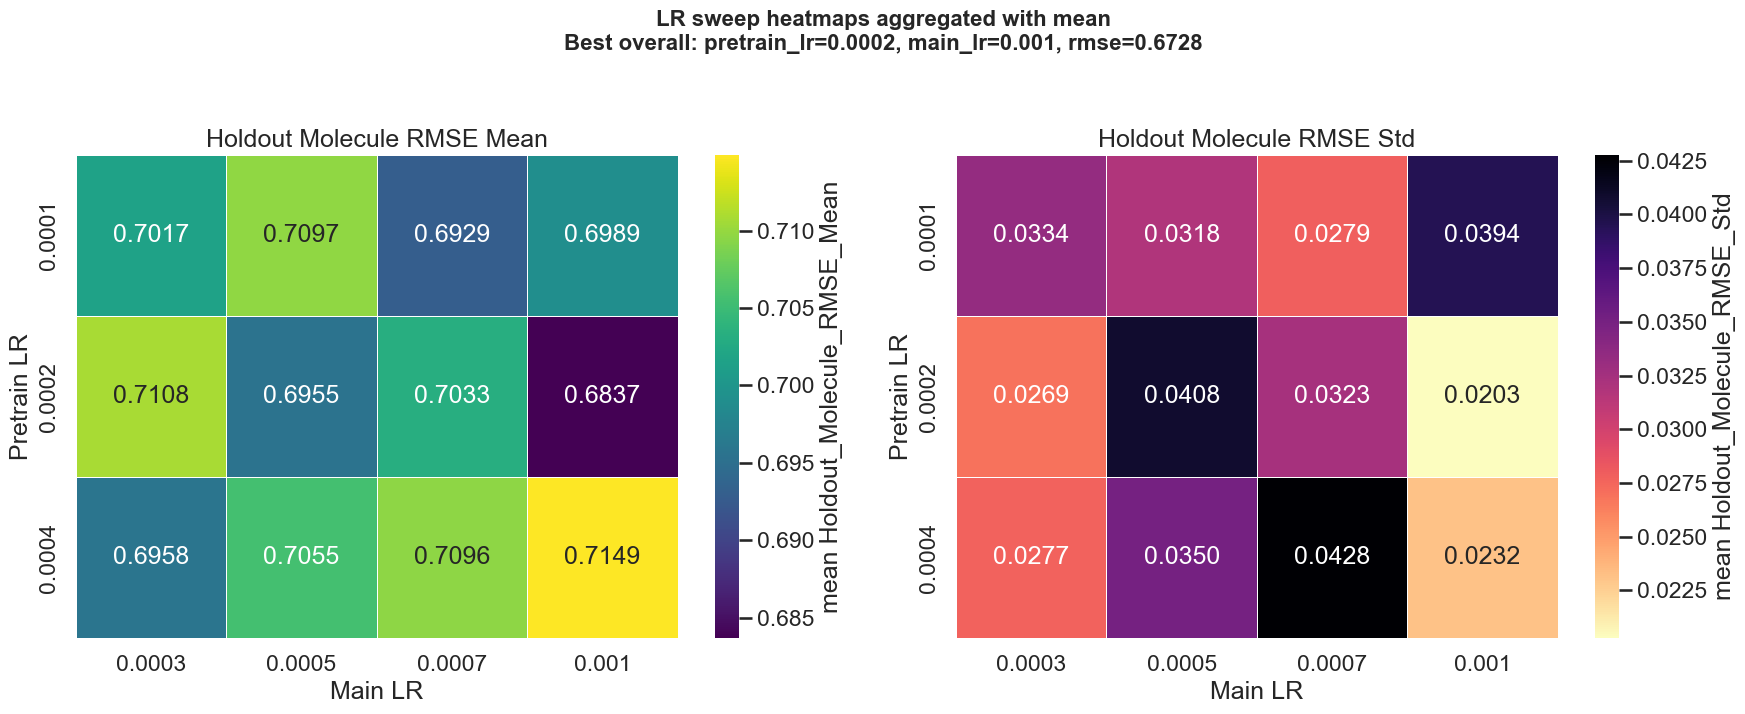

Best LR pairs after aggregation across repeated rows
 Pretrain_LR  Main_LR  Holdout_Molecule_RMSE_Mean  Holdout_Molecule_RMSE_Std
      0.0002   0.0010                    0.683680                   0.020278
      0.0001   0.0007                    0.692900                   0.027858
      0.0002   0.0005                    0.695508                   0.040823
      0.0004   0.0003                    0.695844                   0.027681
      0.0001   0.0010                    0.698920                   0.039448
      0.0001   0.0003                    0.701705                   0.033360
      0.0002   0.0007                    0.703282                   0.032329
      0.0004   0.0005                    0.705514                   0.035048
      0.0004   0.0007                    0.709646                   0.042777
      0.0001   0.0005                    0.709678                   0.031820



In [97]:
# ==============================================================================
# CHANGELOG
# ==============================================================================
# v1.0
# - Load lr_sweep_holdout_results.csv and inspect LR sweep results.
# - Print overall best learning-rate pair using lowest mean RMSE.
# - Print best learning-rate pair for each term, default grouped by Dataset.
# - Plot two seaborn heatmaps:
#     1. Mean holdout molecule RMSE
#     2. Std of holdout molecule RMSE
# - Aggregate repeated rows across the same LR pair with a selectable reduction.
# - Save pivot tables to CSV for easier inspection outside Python.
# ==============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================================================================
# USER SETTINGS
# ==============================================================================
CSV_PATH = r"gat_lr_sweep_holdout_results.csv"

# Which column defines the "term" you want separate best results for.
# From your screenshot this is probably "Dataset".
TERM_COLUMN = "Dataset"

# Main metric columns from your sweep table
RMSE_MEAN_COL = "Holdout_Molecule_RMSE_Mean"
RMSE_STD_COL = "Holdout_Molecule_RMSE_Std"
PRETRAIN_LR_COL = "Pretrain_LR"
MAIN_LR_COL = "Main_LR"

# How to aggregate if multiple rows have the same (Pretrain_LR, Main_LR)
# and maybe differ by Dataset / Sweep / other settings.
HEATMAP_AGG_FUNC = "mean"   # common choices: "mean", "min", "median"

# Whether to save pivot tables and figures
SAVE_OUTPUTS = True
OUTPUT_DIR = r"C:\Users\kjo02\Desktop\project\dat676_project\model\lr_sweep_analysis"

# Plot settings
FIGSIZE = (18, 7)
ANNOTATE = True
FMT = ".4f"
C_MAP_MEAN = "viridis"
C_MAP_STD = "magma_r"


# ==============================================================================
# HELPERS
# ==============================================================================
def ensure_output_dir(path: str) -> None:
    if SAVE_OUTPUTS:
        os.makedirs(path, exist_ok=True)


def check_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns: {missing}\n"
            f"Available columns are:\n{df.columns.tolist()}"
        )


def sort_lr_values(values: pd.Series) -> list:
    """
    Sort learning rates numerically, even if they are read as strings.
    """
    numeric_values = pd.to_numeric(values, errors="coerce")
    if numeric_values.notna().all():
        return sorted(numeric_values.unique())
    return sorted(values.astype(str).unique(), key=lambda x: float(x))


def format_best_row(row: pd.Series) -> str:
    return (
        f"pretrain_lr={row[PRETRAIN_LR_COL]}, "
        f"main_lr={row[MAIN_LR_COL]}, "
        f"{RMSE_MEAN_COL}={row[RMSE_MEAN_COL]:.6f}, "
        f"{RMSE_STD_COL}={row[RMSE_STD_COL]:.6f}"
    )


def choose_best_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Choose best rows by:
    1. lowest mean RMSE
    2. lowest std
    3. lowest pretrain lr
    4. lowest main lr
    """
    work = df.copy()

    work[PRETRAIN_LR_COL] = pd.to_numeric(work[PRETRAIN_LR_COL], errors="coerce")
    work[MAIN_LR_COL] = pd.to_numeric(work[MAIN_LR_COL], errors="coerce")
    work[RMSE_MEAN_COL] = pd.to_numeric(work[RMSE_MEAN_COL], errors="coerce")
    work[RMSE_STD_COL] = pd.to_numeric(work[RMSE_STD_COL], errors="coerce")

    work = work.sort_values(
        by=[RMSE_MEAN_COL, RMSE_STD_COL, PRETRAIN_LR_COL, MAIN_LR_COL],
        ascending=[True, True, True, True],
    )
    return work


def aggregate_for_heatmap(df: pd.DataFrame, value_col: str, agg_func: str) -> pd.DataFrame:
    """
    Build pivot table over pretrain lr x main lr for a chosen metric.
    """
    pivot = pd.pivot_table(
        df,
        index=PRETRAIN_LR_COL,
        columns=MAIN_LR_COL,
        values=value_col,
        aggfunc=agg_func,
    )

    # Ensure sorted numeric axes
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)
    return pivot


# ==============================================================================
# LOAD
# ==============================================================================
df = pd.read_csv(CSV_PATH)

required_columns = [
    TERM_COLUMN,
    RMSE_MEAN_COL,
    RMSE_STD_COL,
    PRETRAIN_LR_COL,
    MAIN_LR_COL,
]
check_required_columns(df, required_columns)

# Force numeric where appropriate
df[RMSE_MEAN_COL] = pd.to_numeric(df[RMSE_MEAN_COL], errors="coerce")
df[RMSE_STD_COL] = pd.to_numeric(df[RMSE_STD_COL], errors="coerce")
df[PRETRAIN_LR_COL] = pd.to_numeric(df[PRETRAIN_LR_COL], errors="coerce")
df[MAIN_LR_COL] = pd.to_numeric(df[MAIN_LR_COL], errors="coerce")

# Drop broken rows if any
df = df.dropna(subset=[RMSE_MEAN_COL, RMSE_STD_COL, PRETRAIN_LR_COL, MAIN_LR_COL]).copy()

ensure_output_dir(OUTPUT_DIR)

print("=" * 80)
print("Loaded LR sweep results")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print()

print("=" * 80)
print("Unique values")
print("=" * 80)
print(f"{TERM_COLUMN}: {sorted(df[TERM_COLUMN].astype(str).unique().tolist())}")
print(f"{PRETRAIN_LR_COL}: {sorted(df[PRETRAIN_LR_COL].unique().tolist())}")
print(f"{MAIN_LR_COL}: {sorted(df[MAIN_LR_COL].unique().tolist())}")
print()


# ==============================================================================
# BEST OVERALL
# ==============================================================================
overall_sorted = choose_best_rows(df)
best_overall = overall_sorted.iloc[0]

print("=" * 80)
print("Overall best LR pair")
print("=" * 80)
print(format_best_row(best_overall))
print()


# ==============================================================================
# BEST FOR EACH TERM
# ==============================================================================
print("=" * 80)
print(f"Best LR pair for each {TERM_COLUMN}")
print("=" * 80)

best_per_term_rows = []
for term_value, group in df.groupby(TERM_COLUMN, dropna=False):
    group_sorted = choose_best_rows(group)
    best_row = group_sorted.iloc[0].copy()
    best_per_term_rows.append(best_row)

    print(f"{TERM_COLUMN} = {term_value}")
    print(f"  {format_best_row(best_row)}")

best_per_term_df = pd.DataFrame(best_per_term_rows).reset_index(drop=True)
print()

if SAVE_OUTPUTS:
    best_per_term_path = os.path.join(OUTPUT_DIR, "best_lr_per_term.csv")
    best_per_term_df.to_csv(best_per_term_path, index=False)

    best_overall_path = os.path.join(OUTPUT_DIR, "best_lr_overall.csv")
    pd.DataFrame([best_overall]).to_csv(best_overall_path, index=False)


# ==============================================================================
# AGGREGATED TABLES FOR HEATMAPS
# ==============================================================================
rmse_mean_pivot = aggregate_for_heatmap(df, RMSE_MEAN_COL, HEATMAP_AGG_FUNC)
rmse_std_pivot = aggregate_for_heatmap(df, RMSE_STD_COL, HEATMAP_AGG_FUNC)

print("=" * 80)
print("Aggregated RMSE mean heatmap table")
print("=" * 80)
print(rmse_mean_pivot)
print()

print("=" * 80)
print("Aggregated RMSE std heatmap table")
print("=" * 80)
print(rmse_std_pivot)
print()

if SAVE_OUTPUTS:
    rmse_mean_pivot.to_csv(os.path.join(OUTPUT_DIR, "heatmap_rmse_mean_pivot.csv"))
    rmse_std_pivot.to_csv(os.path.join(OUTPUT_DIR, "heatmap_rmse_std_pivot.csv"))


# ==============================================================================
# PLOTTING
# ==============================================================================
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Heatmap 1: mean RMSE
sns.heatmap(
    rmse_mean_pivot,
    ax=axes[0],
    cmap=C_MAP_MEAN,
    annot=ANNOTATE,
    fmt=FMT,
    linewidths=0.5,
    cbar_kws={"label": f"{HEATMAP_AGG_FUNC} {RMSE_MEAN_COL}"},
)
axes[0].set_title("Holdout Molecule RMSE Mean")
axes[0].set_xlabel("Main LR")
axes[0].set_ylabel("Pretrain LR")

# Heatmap 2: RMSE std
sns.heatmap(
    rmse_std_pivot,
    ax=axes[1],
    cmap=C_MAP_STD,
    annot=ANNOTATE,
    fmt=FMT,
    linewidths=0.5,
    cbar_kws={"label": f"{HEATMAP_AGG_FUNC} {RMSE_STD_COL}"},
)
axes[1].set_title("Holdout Molecule RMSE Std")
axes[1].set_xlabel("Main LR")
axes[1].set_ylabel("Pretrain LR")

plt.suptitle(
    f"LR sweep heatmaps aggregated with {HEATMAP_AGG_FUNC}\n"
    f"Best overall: pretrain_lr={best_overall[PRETRAIN_LR_COL]}, "
    f"main_lr={best_overall[MAIN_LR_COL]}, "
    f"rmse={best_overall[RMSE_MEAN_COL]:.4f}",
    y=1.03,
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

if SAVE_OUTPUTS:
    fig_path_png = os.path.join(OUTPUT_DIR, "lr_sweep_heatmaps.png")
    fig_path_pdf = os.path.join(OUTPUT_DIR, "lr_sweep_heatmaps.pdf")
    plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
    plt.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()


# ==============================================================================
# OPTIONAL: ALSO SHOW BEST COMBINATIONS AFTER AGGREGATING OVER REPEATED ROWS
# ==============================================================================
aggregated_pairs = (
    df.groupby([PRETRAIN_LR_COL, MAIN_LR_COL], as_index=False)
    .agg({
        RMSE_MEAN_COL: HEATMAP_AGG_FUNC,
        RMSE_STD_COL: HEATMAP_AGG_FUNC,
    })
    .sort_values(
        by=[RMSE_MEAN_COL, RMSE_STD_COL, PRETRAIN_LR_COL, MAIN_LR_COL],
        ascending=[True, True, True, True]
    )
)

print("=" * 80)
print("Best LR pairs after aggregation across repeated rows")
print("=" * 80)
print(aggregated_pairs.head(10).to_string(index=False))
print()

if SAVE_OUTPUTS:
    aggregated_pairs.to_csv(os.path.join(OUTPUT_DIR, "aggregated_lr_pairs_ranked.csv"), index=False)